# Day 4 – Project 1: Rhythmic Head Movements in Navigating Rats

**Python for Animal Behavioral Analysis Workshop**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_REPO/Day4_Project1_HeadMovements.ipynb)

---

## Learning Objectives

By the end of this notebook, you will:
1. Load and explore rigid-body tracking data (roll, yaw, pitch) from a rat path-integration task
2. Apply bandpass filtering to isolate rhythmic head movements
3. Understand and apply the **Hilbert transform** to extract instantaneous frequency and amplitude
4. Compare the Hilbert-derived frequency to a spectrogram representation
5. Visualise how head-movement rhythms change between outbound foraging and inbound homing
6. Connect your findings to the literature on sniff-synchronized sensing (Findley et al. 2021)

---

## Background & Motivation

> *"Mice actively modulate their sniffing frequency and head direction to search for odour gradients — a form of active sensing that is tightly coupled to rhythmic head movements."*
> — Findley et al., eLife 2021

In that study, mice performing an olfactory search task showed **high-frequency (5–15 Hz) head-casting oscillations** that were phase-locked to the sniff cycle. The key insight: the brain does not passively receive sensory input — it **actively samples** the environment through rhythmic motor patterns.

**Our question today:** In a rat **path integration task** (outbound foraging → inbound homing), can we detect similar rhythmic, high-frequency head movements? Do they differ between the outbound and inbound phases of the task?

---

## Dataset Description

We use tracking data from Day 2, collected during a **rat path integration task**. In this task:
- **Outbound phase**: Rat forages away from a home base, collecting a food reward
- **Inbound phase**: Rat returns home using path integration (no external cues)

| Column | Type | Description | Units |
|--------|------|-------------|-------|
| `time` | float | Time since trial start | seconds |
| `trial_id` | int | Trial number | — |
| `frame` | int | Frame index | — |
| `success` | bool | Did rat return home? | — |
| `visible` | bool | Was rat visible? | — |
| `x`, `y`, `z` | float | 3D position | cm |
| `roll` | float | Roll angle | degrees |
| `yaw` | float | Yaw angle (heading) | degrees |
| `pitch` | float | Pitch angle (nose up/down) | degrees |
| `rearing` | bool | Is rat rearing? | — |
| `goal_x`, `goal_z` | float | Home base position | cm |
| `session_id` | str | Session identifier | — |

## Setup

Run this cell first to install required packages and import libraries.

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import butter, filtfilt, welch, hilbert, spectrogram
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✓ All packages loaded successfully!")
print(f"  numpy version: {np.__version__}")

✓ All packages loaded successfully!
  numpy version: 2.1.3


## Part 1: Load and Explore the Data

### 1.1 Load Tracking Data

We'll load the same dataset from Day 2 — rigid-body tracking of a rat during a path integration task.

In [2]:
# Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# Load the dataset
DATA_PATH = '../data/rat_pi/processed_long_trials.csv'

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (117388, 16)

Columns: ['comp_time', 'time', 'trial_id', 'frame', 'success', 'visible', 'x', 'y', 'z', 'roll', 'yaw', 'pitch', 'rearing', 'goal_x', 'goal_z', 'session_id']

First few rows:


,comp_time,time,trial_id,frame,success,visible,x,y,z,roll,yaw,pitch,rearing,goal_x,goal_z,session_id
0,1.642678e+09,0.00,0,0,1,1,-0.177946,0.684947,-0.538020,17.219877,130.408251,1.626639,1,-0.222463,-0.506765,20220120-122427
1,1.642678e+09,0.02,0,1,1,1,-0.176145,0.677317,-0.534851,15.862311,137.391134,-1.968877,1,-0.222463,-0.506765,20220120-122427
2,1.642678e+09,0.04,0,2,1,1,-0.173438,0.669224,-0.531853,11.622204,142.254633,-6.752198,0,-0.222463,-0.506765,20220120-122427
3,1.642678e+09,0.06,0,3,1,1,-0.171214,0.657547,-0.527501,10.051063,145.591786,-10.945343,0,-0.222463,-0.506765,20220120-122427
4,1.642678e+09,0.08,0,4,1,1,-0.168450,0.649601,-0.524621,9.225046,146.075703,-14.109203,0,-0.222463,-0.506765,20220120-122427


In [3]:
# ── Quick data overview ──────────────────────────────────────────────────────
print("=== Data Overview ===")
print(f"Number of trials: {df['trial_id'].nunique()}")
print(f"Number of sessions: {df['session_id'].nunique()}")
print(f"Total frames: {len(df)}")

# Infer sampling frequency from time column
dt = df['time'].diff().median()
fs = 1.0 / dt
print(f"\nSampling frequency: {fs:.1f} Hz  (dt ≈ {dt*1000:.1f} ms)")

# Check angular columns
print("\n=== Head Orientation Summary ===")
for col in ['roll', 'yaw', 'pitch']:
    print(f"  {col}: min={df[col].min():.1f}°  max={df[col].max():.1f}°  "
          f"mean={df[col].mean():.1f}°")

# Outbound vs inbound breakdown
print(f"\n=== Task Phase ===")
print(df['success'].value_counts())

=== Data Overview ===
Number of trials: 139
Number of sessions: 5
Total frames: 117388

Sampling frequency: 50.0 Hz  (dt ≈ 20.0 ms)

=== Head Orientation Summary ===
  roll: min=-59.2°  max=74.9°  mean=-1.3°
  yaw: min=-180.0°  max=180.0°  mean=-13.1°
  pitch: min=-142.0°  max=55.5°  mean=-45.5°

=== Task Phase ===
success
1    100567
0     16821
Name: count, dtype: int64


### 1.2 Visualise a Single Trial

Before any signal processing, let's look at the raw head orientation signals to build intuition.

Trial 0: 739 frames  (14.8 s)


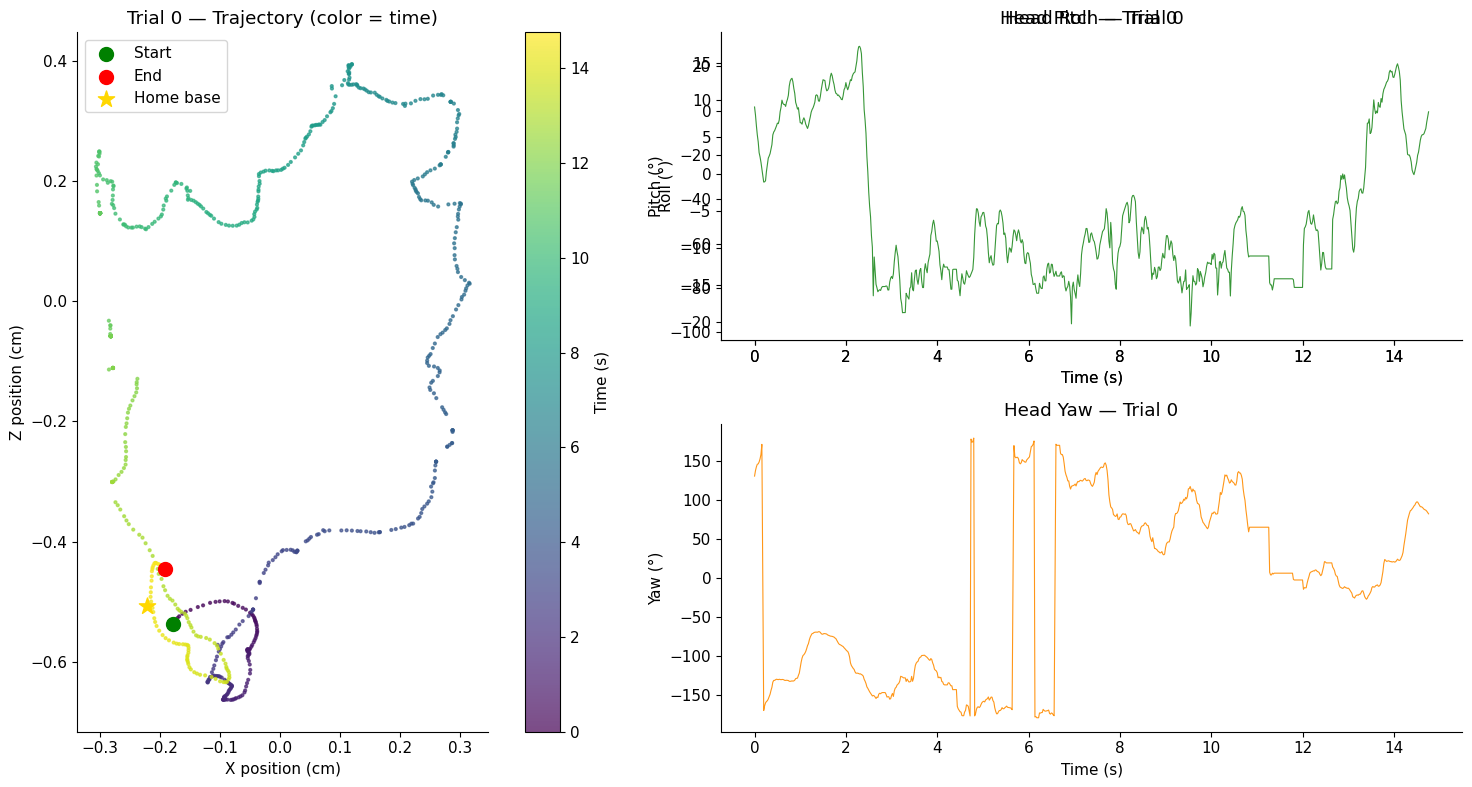


Observation: Can you see any oscillatory patterns in pitch or roll?


In [4]:
# Pick one trial to explore
TRIAL_ID = df['trial_id'].unique()[0]
trial = df[df['trial_id'] == TRIAL_ID].copy().reset_index(drop=True)
print(f"Trial {TRIAL_ID}: {len(trial)} frames  ({len(trial)/fs:.1f} s)")

# Plot trajectory + head angles
fig = plt.figure(figsize=(16, 8))
gs = gridspec.GridSpec(2, 2, figure=fig)

# 2D trajectory
ax0 = fig.add_subplot(gs[:, 0])
sc = ax0.scatter(trial['x'], trial['z'], c=trial['time'],
                 cmap='viridis', s=4, alpha=0.7)
ax0.scatter(*trial[['x','z']].iloc[0], s=100, color='green', zorder=5, label='Start')
ax0.scatter(*trial[['x','z']].iloc[-1], s=100, color='red', zorder=5, label='End')
ax0.scatter(trial['goal_x'].iloc[0], trial['goal_z'].iloc[0],
            s=150, marker='*', color='gold', zorder=6, label='Home base')
plt.colorbar(sc, ax=ax0, label='Time (s)')
ax0.set_xlabel('X position (cm)')
ax0.set_ylabel('Z position (cm)')
ax0.set_title(f'Trial {TRIAL_ID} — Trajectory (color = time)')
ax0.legend()
ax0.set_aspect('equal')

# Head angles over time
for i, (col, color) in enumerate(zip(['roll','yaw','pitch'],
                                      ['steelblue','darkorange','forestgreen'])):
    ax = fig.add_subplot(gs[i % 2, 1])
    ax.plot(trial['time'], trial[col], color=color, linewidth=0.8, alpha=0.9)
    ax.set_ylabel(f'{col.capitalize()} (°)')
    ax.set_xlabel('Time (s)')
    ax.set_title(f'Head {col.capitalize()} — Trial {TRIAL_ID}')

plt.tight_layout()
plt.show()

print("\nObservation: Can you see any oscillatory patterns in pitch or roll?")

---
## Part 2: Signal Processing — Bandpass Filtering

### 2.1 The Challenge: Extracting Rhythmic Signals

Raw head-angle data contains multiple overlapping components:
- **Slow postural drift** (< 2 Hz): overall head orientation during navigation
- **Rhythmic active sensing** (5–15 Hz): the sniff-coupled head-casting we want to detect
- **High-frequency noise** (> 20 Hz): sensor noise, tracking jitter

We need to **isolate the 5–15 Hz band** using a bandpass filter.

### 2.2 The Butterworth Bandpass Filter

A Butterworth filter has a maximally flat passband — it doesn't distort frequencies inside the passband. The filter is defined by:

$$H(j\omega) = \frac{1}{\sqrt{1 + \left(\frac{\omega}{\omega_c}\right)^{2N}}}$$

where $N$ is the filter order and $\omega_c$ is the cutoff frequency. We use `filtfilt` (zero-phase, forward+backward filtering) to avoid phase distortion.

**Key parameters:**
- `lowcut` — lowest frequency to keep (Hz)
- `highcut` — highest frequency to keep (Hz)  
- `order` — filter steepness (2 = gentle, 4 = sharp)

In [5]:
# ── Helper functions ─────────────────────────────────────────────────────────

def moving_mean_filter(signal, window):
    """Simple moving average filter to remove slow drift."""
    import pandas as pd
    return pd.Series(signal).rolling(window=window, center=True,
                                     min_periods=1).mean().values

def butter_bandpass_filter(data, lowcut, highcut, fs, order=2):
    """
    Apply a zero-phase Butterworth bandpass filter.

    Parameters
    ----------
    data    : 1D array — input signal
    lowcut  : float — lower cutoff frequency (Hz)
    highcut : float — upper cutoff frequency (Hz)
    fs      : float — sampling frequency (Hz)
    order   : int   — filter order (steepness)

    Returns
    -------
    filtered : 1D array — bandpass-filtered signal
    """
    nyq = 0.5 * fs
    low  = lowcut  / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

print("✓ Filter functions defined!")

✓ Filter functions defined!


### 2.3 Interactive Parameter Explorer 🎛️

Use the widget below to explore how filter parameters affect the pitch signal.
You can adjust:
- **lowcut / highcut** — define the frequency band of interest
- **order** — filter steepness
- **smoothing window** — size of pre-filter moving average

> **Tip**: Start with `lowcut=5, highcut=15, order=2` to replicate the Findley et al. parameter range.

In [6]:
from ipywidgets import interact, FloatSlider, IntSlider
import ipywidgets as widgets

# Work on a single trial for interactive exploration
pitch_raw = trial['pitch'].values.copy()
t = trial['time'].values

def explore_filter(lowcut=5.0, highcut=15.0, order=2, smooth_window=10):
    """Interactive bandpass filter explorer."""
    # Step 1: unwrap angles (handles 360° wrap-around)
    pitch = np.unwrap(pitch_raw, period=360)

    # Step 2: remove slow drift with moving average
    pitch = pitch - moving_mean_filter(pitch, smooth_window)

    # Step 3: bandpass filter
    try:
        filtered = butter_bandpass_filter(pitch, lowcut, highcut, fs, order)
    except Exception as e:
        print(f"Filter error: {e} — try adjusting cutoffs.")
        return

    # Power spectrum
    freqs, power = welch(pitch - moving_mean_filter(pitch, smooth_window),
                         fs=fs, nperseg=int(fs*2))

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Raw vs filtered
    axes[0].plot(t, pitch, alpha=0.5, color='grey', linewidth=0.8, label='Detrended')
    axes[0].plot(t, filtered, color='crimson', linewidth=1.2, label='Filtered')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Pitch (°, detrended)')
    axes[0].set_title('Raw vs Bandpass-Filtered Pitch')
    axes[0].legend()

    # Power spectrum with filter band highlighted
    axes[1].semilogy(freqs, power, color='steelblue', linewidth=1.5)
    axes[1].axvspan(lowcut, highcut, alpha=0.2, color='crimson', label=f'{lowcut}–{highcut} Hz band')
    axes[1].set_xlabel('Frequency (Hz)')
    axes[1].set_ylabel('Power spectral density')
    axes[1].set_title('Power Spectrum')
    axes[1].set_xlim(0, fs/2)
    axes[1].legend()

    # Filtered signal zoomed in (first 5 seconds)
    mask = t < t[0] + 5
    axes[2].plot(t[mask], filtered[mask], color='crimson', linewidth=1.5)
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('Filtered pitch (°)')
    axes[2].set_title('Zoom: First 5 Seconds')

    plt.suptitle(f'Filter: {lowcut}–{highcut} Hz, order={order}, smooth={smooth_window}',
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
# Create the interactive widget
interact(explore_filter,
         lowcut  = FloatSlider(min=1.0, max = 6.0, step=0.5, value=5.0,
                               description='Low (Hz)', continuous_update=False),
         highcut = FloatSlider(min=10, max=15.0, step=0.5, value=15.0,
                               description='High (Hz)', continuous_update=False),
         order   = IntSlider(min=1, max=5, step=1, value=2,
                             description='Order', continuous_update=False),
         smooth_window = IntSlider(min=1, max=5, step=1, value=10,
                                   description='Smooth win', continuous_update=False));

interactive(children=(FloatSlider(value=5.0, continuous_update=False, description='Low (Hz)', max=6.0, min=1.0…

---
## Part 3: The Hilbert Transform — Extracting Instantaneous Frequency & Amplitude

### 3.1 What Does the Hilbert Transform Do?

After bandpass filtering, we have an oscillatory signal — but its frequency and amplitude may **change over time**. The power spectrum (Welch) gives us the *average* frequency content, but we want to know:

- **How fast is the rat oscillating its head *right now*?** → Instantaneous frequency
- **How strongly is it oscillating *right now*?** → Instantaneous amplitude (envelope)

The **Hilbert transform** answers both questions by constructing the **analytic signal**.

### 3.2 The Analytic Signal — Intuition

Think of a swinging pendulum viewed from the side — you see a 1D oscillation. But if you could view it from above, you'd see it tracing a **circle**. The Hilbert transform recovers this "circular" view from the 1D signal.

Given a real signal $x(t)$, the **analytic signal** is:

$$z(t) = x(t) + j \cdot \mathcal{H}[x(t)]$$

where $\mathcal{H}$ is the Hilbert transform. The Hilbert transform creates a **90° phase-shifted** copy of the signal (like cosine → sine).

From this complex signal we extract:

- **Instantaneous amplitude** (envelope): $A(t) = |z(t)| = \sqrt{x(t)^2 + \mathcal{H}[x(t)]^2}$
- **Instantaneous phase**: $\phi(t) = \text{arctan2}\big(\mathcal{H}[x(t)],\; x(t)\big)$
- **Instantaneous frequency**: $f(t) = \frac{1}{2\pi} \frac{d\phi(t)}{dt}$

### 3.3 Why Bandpass First?

The Hilbert transform gives meaningful instantaneous frequency **only for narrowband signals** (signals dominated by a single oscillation at each moment). If the signal has energy at many frequencies simultaneously, the "instantaneous frequency" becomes an ill-defined average.

**Our pipeline:**
1. Bandpass filter → isolate the 5–15 Hz band → narrowband signal  
2. Hilbert transform → extract envelope and instantaneous frequency

> **Key takeaway:** The Hilbert transform does NOT decompose a signal into frequencies (that's what Fourier/wavelets do). Instead, it tracks how a *single oscillatory component* evolves over time.

### 3.4 Demo: Hilbert Transform on a Synthetic Signal

Let's build intuition with a signal whose frequency we control — a **chirp** (frequency increases over time).

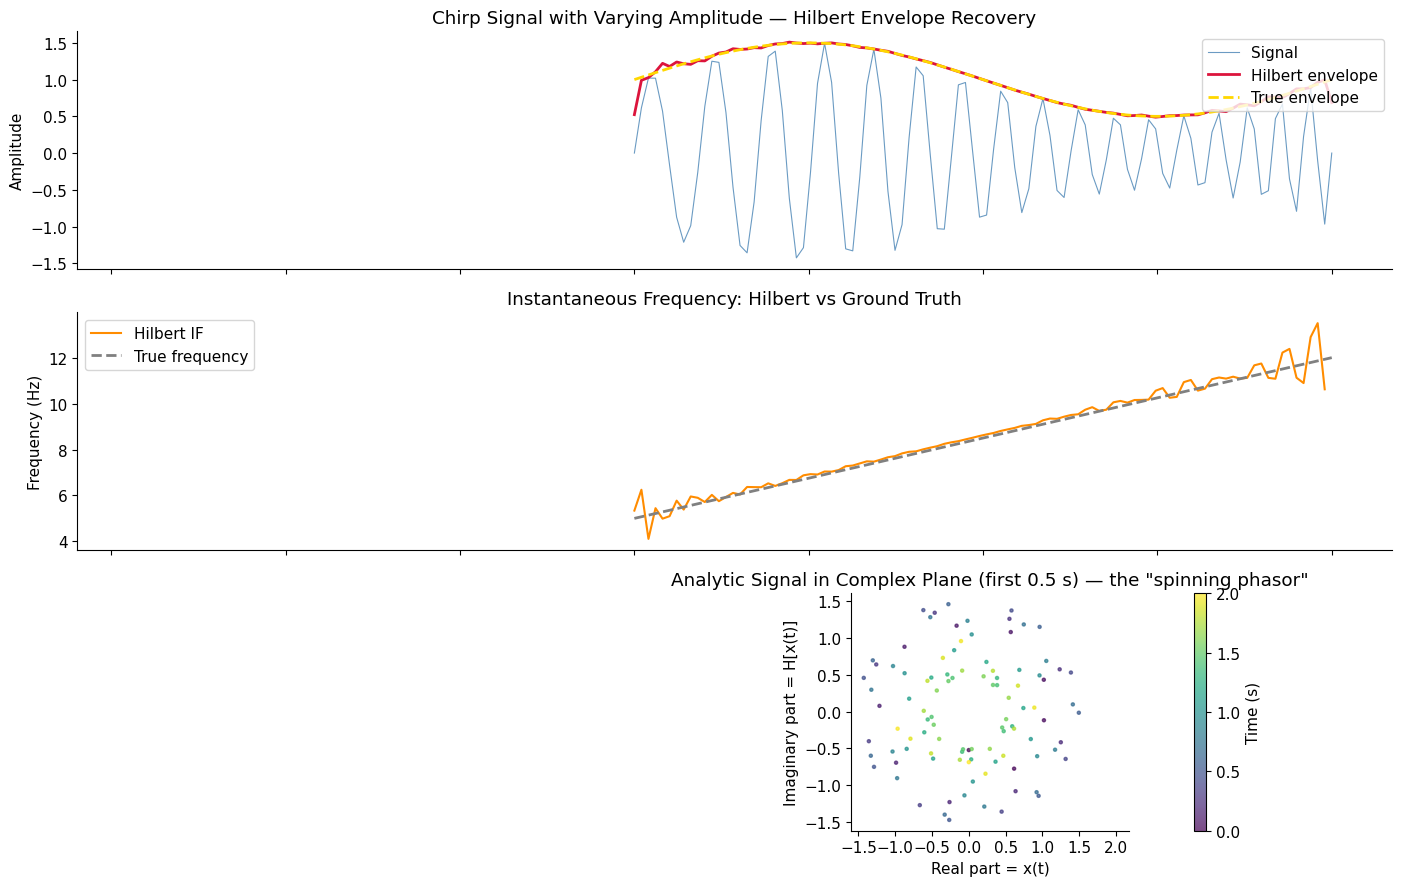

The Hilbert transform recovers both the envelope and instantaneous frequency!
Notice: the phasor spirals outward as amplitude grows, and spins faster as frequency increases.


In [9]:
# ── Demo: Hilbert transform on a chirp signal ────────────────────────────────
# A chirp is a signal whose frequency changes linearly over time.
# We know the ground truth — perfect for validating the Hilbert approach!

duration = 2.0  # seconds
t_demo = np.linspace(0, duration, int(fs * duration))

# Create a chirp: frequency goes from 5 Hz to 12 Hz
f_start, f_end = 5.0, 12.0
# Instantaneous frequency at each time point (linear ramp)
f_true = f_start + (f_end - f_start) * t_demo / duration
# Phase is the integral of frequency: φ(t) = 2π ∫ f(t') dt'
phase_true = 2 * np.pi * (f_start * t_demo + 0.5 * (f_end - f_start) * t_demo**2 / duration)
# Amplitude envelope: oscillates between 0.5 and 1.5
amp_true = 1.0 + 0.5 * np.sin(2 * np.pi * 0.5 * t_demo)

# The signal
signal_demo = amp_true * np.sin(phase_true)

# Apply Hilbert transform (scipy)
analytic = hilbert(signal_demo)    # returns the analytic signal z(t)
amp_hilbert  = np.abs(analytic)    # instantaneous amplitude = |z(t)|
phase_hilbert = np.unwrap(np.angle(analytic))  # instantaneous phase
freq_hilbert  = np.diff(phase_hilbert) / (2 * np.pi) * fs  # instantaneous frequency

# ── Visualise ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Signal + envelope
axes[0].plot(t_demo, signal_demo, color='steelblue', linewidth=0.8, alpha=0.8, label='Signal')
axes[0].plot(t_demo, amp_hilbert, color='crimson', linewidth=2, label='Hilbert envelope')
axes[0].plot(t_demo, amp_true, color='gold', linewidth=2, linestyle='--', label='True envelope')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Chirp Signal with Varying Amplitude — Hilbert Envelope Recovery')
axes[0].legend(loc='upper right')

# Instantaneous frequency
axes[1].plot(t_demo[:-1], freq_hilbert, color='darkorange', linewidth=1.5, label='Hilbert IF')
axes[1].plot(t_demo, f_true, color='grey', linewidth=2, linestyle='--', label='True frequency')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_title('Instantaneous Frequency: Hilbert vs Ground Truth')
axes[1].legend()

# Analytic signal in complex plane (shows the "rotating" view)
ax2 = axes[2]
# Show a subset for clarity
n_show = int(4 * fs)  # first 0.5 seconds
colors = t_demo[:n_show]
sc = ax2.scatter(analytic.real[:n_show], analytic.imag[:n_show],
                 c=colors, cmap='viridis', s=5, alpha=0.7)
plt.colorbar(sc, ax=ax2, label='Time (s)')
ax2.set_xlabel('Real part = x(t)')
ax2.set_ylabel('Imaginary part = H[x(t)]')
ax2.set_title('Analytic Signal in Complex Plane (first 0.5 s) — the "spinning phasor"')
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

print("The Hilbert transform recovers both the envelope and instantaneous frequency!")
print("Notice: the phasor spirals outward as amplitude grows, and spins faster as frequency increases.")

### 3.5 Apply to Real Head Movement Data

Now let's build our analysis pipeline using bandpass filtering + Hilbert transform (no EMD needed).

**Pipeline:**
1. Unwrap angles (handle 360° wrap-around)
2. Remove slow drift (moving average subtraction)
3. Bandpass filter (5–15 Hz)
4. Hilbert transform → instantaneous amplitude & frequency

In [25]:
import emd

In [30]:
# ── Bandpass + Hilbert pipeline ──────────────────────────────────────────────

def compute_head_rhythm(angle_signal, fs,
                        lowcut=5.0, highcut=15.0,
                        filter_order=2, smooth_window=10,
                        smooth_freq=9, smooth_phase=5):
    """
    Full pipeline: angle signal → instantaneous frequency & amplitude.

    Steps
    -----
    1. Unwrap angle (handle 360° wrapping)
    2. Remove slow drift (moving average)
    3. Bandpass filter (isolate target frequency band)
    4. Hilbert transform: extract instantaneous phase, frequency, amplitude

    Parameters
    ----------
    angle_signal  : 1D array — raw angle in degrees (roll, yaw, or pitch)
    fs            : float — sampling frequency (Hz)
    lowcut        : float — bandpass lower cutoff (Hz)
    highcut       : float — bandpass upper cutoff (Hz)
    filter_order  : int   — Butterworth filter order
    smooth_window : int   — moving average window (frames) for detrending
    smooth_freq   : int   — smoothing window for instantaneous frequency
    smooth_phase  : int   — smoothing window for instantaneous phase

    Returns
    -------
    t_axis   : 1D array — time axis (seconds)
    filtered : 1D array — bandpass-filtered signal
    IP       : 2D array — instantaneous phase  (n_frames, 1)
    IF       : 2D array — instantaneous frequency (n_frames, 1)
    IA       : 2D array — instantaneous amplitude (n_frames, 1)
    """
    # Step 1: Unwrap to remove discontinuities at ±180°
    unwrapped = np.unwrap(angle_signal, period=360)

    # Step 2: Remove slow drift
    detrended = unwrapped - moving_mean_filter(unwrapped, smooth_window)

    # Step 3: Bandpass filter
    filtered = butter_bandpass_filter(detrended, lowcut, highcut, fs, filter_order)

    # Step 4: Hilbert transform on the filtered signal
    IP, IF, IA = emd.spectra.frequency_transform(
        filtered, fs, 'hilbert',
        smooth_freq=smooth_freq,
        smooth_phase=smooth_phase
    )
    # IP, IF, IA shape: (n_frames, 1)

    t_axis = np.arange(len(filtered)) / fs
    return t_axis, filtered, IP, IF, IA  # fixed return order


# ── Run on example trial ──────────────────────────────────────────────────────

print("Running bandpass + Hilbert pipeline on trial pitch signal...")

# FIX: unpack in the correct order matching the return statement
t_ax, pitch_filt, IP, IF, IA = compute_head_rhythm(
    trial['pitch'].values, fs,
    lowcut=5.0, highcut=15.0
)

print(f"  Input length    : {len(trial)} frames ({len(trial)/fs:.1f} s)")
print(f"  Filtered length : {len(pitch_filt)} frames")
print(f"  IF shape        : {IF.shape}")
print(f"  Median IF       : {np.nanmedian(IF):.2f} Hz")
print(f"  Mean amplitude  : {np.nanmean(IA):.3f}°")
print("\n✓ Pipeline complete!")



Running bandpass + Hilbert pipeline on trial pitch signal...
  Input length    : 739 frames (14.8 s)
  Filtered length : 739 frames
  IF shape        : (739, 1)
  Median IF       : 7.26 Hz
  Mean amplitude  : 2.804°

✓ Pipeline complete!


In [31]:

# ── Interactive explorer ──────────────────────────────────────────────────────

def explore_hilbert(lowcut=5.0, highcut=15.0, order=2, smooth_window=10,
                    smooth_freq=9, smooth_phase=5):
    """Interactive explorer for Hilbert transform parameters."""
    pitch_sig = trial['pitch'].values
    pitch_raw = pitch_sig                          # FIX: define pitch_raw for the plot
    t_trial   = trial['time'].values

    try:
        t_ax, pitch_filt, IP, IF, IA = compute_head_rhythm(  # FIX: correct unpack order
            pitch_sig, fs,
            lowcut=lowcut, highcut=highcut,
            filter_order=order, smooth_window=smooth_window,
            smooth_freq=smooth_freq, smooth_phase=smooth_phase
        )
    except Exception as e:
        print(f"Error: {e}")
        return

    # FIX: n_imfs derived from IF columns (Hilbert returns one column per
    #      input channel; with a 1-D signal this is 1, but kept general)
    n_imfs = IF.shape[1]

    # Select component with peak frequency in target band
    mean_if = np.nanmedian(IF, axis=0)            # shape: (n_imfs,)
    in_band = (mean_if >= lowcut) & (mean_if <= highcut)
    best_imf = int(np.argmax(IA[:, in_band].mean(axis=0))) if in_band.any() else 0
    best_idx = int(np.where(in_band)[0][best_imf]) if in_band.any() else 0

    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=False)

    # ── Components ──
    offset = 0
    for k in range(min(n_imfs, 5)):
        axes[0].plot(t_ax, IA[:, k] + offset,        # plot envelope per component
                     linewidth=0.8,
                     label=f'Component {k+1} (median f={mean_if[k]:.1f} Hz)',
                     alpha=0.85)
        offset += np.ptp(IA[:, k]) * 1.2
    axes[0].plot(t_ax, pitch_filt, color='crimson', linewidth=1.5,
                 label='Bandpass-filtered signal')
    axes[0].set_ylabel('Amplitude (°, offset)')
    axes[0].set_title('Hilbert Components (envelopes, first 5)')
    axes[0].legend(fontsize=8, loc='upper right')
    axes[0].set_xlabel('Time (s)')

    # ── Best component: filtered signal + amplitude envelope ──
    axes[1].plot(t_ax, pitch_filt, color='steelblue',
                 linewidth=0.9, label='Bandpass-filtered signal', alpha=0.8)
    axes[1].plot(t_ax,  IA[:, best_idx], color='crimson',
                 linewidth=1.5, label='Instantaneous amplitude (envelope)')
    axes[1].plot(t_ax, -IA[:, best_idx], color='crimson', linewidth=1.5, alpha=0.5)
    axes[1].set_ylabel('Amplitude (°)')
    axes[1].set_title(
        f'Best component in {lowcut}–{highcut} Hz band (idx {best_idx+1}) + Envelope')
    axes[1].legend()
    axes[1].set_xlabel('Time (s)')

    # ── Instantaneous frequency ──
    axes[2].plot(t_ax, IF[:, best_idx], color='darkorange',
                 linewidth=0.9, alpha=0.8, label='Instantaneous frequency')
    twin = axes[2].twinx()
    twin.plot(t_ax, pitch_raw, color='crimson', linewidth=1.5,   # FIX: now defined
              label='Raw pitch', alpha=0.8)
    twin.set_ylabel('Raw pitch (°)')
    twin.legend(loc='upper left')
    axes[2].axhline(lowcut,  color='grey', linestyle='--', linewidth=1,
                    label=f'Band: {lowcut}–{highcut} Hz')
    axes[2].axhline(highcut, color='grey', linestyle='--', linewidth=1)
    axes[2].set_ylim(0, fs / 2)
    axes[2].set_ylabel('Frequency (Hz)')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_title('Instantaneous Frequency over Time')
    axes[2].legend(loc='upper right')

    plt.suptitle(
        f'Hilbert Analysis | Filter: {lowcut}–{highcut} Hz, order={order}', y=1.01)
    plt.tight_layout()
    plt.show()

    print(f"Median instantaneous frequency (component {best_idx+1}): "
          f"{np.nanmedian(IF[:, best_idx]):.2f} Hz")


# FIX: interact target name matches the function defined above
interact(explore_hilbert,                          # was: explore_emd (undefined)
         lowcut        = FloatSlider(min=1.0, max=20.0, step=0.5, value=5.0,
                                     description='Low (Hz)',   continuous_update=False),
         highcut       = FloatSlider(min=2.0, max=40.0, step=0.5, value=15.0,
                                     description='High (Hz)',  continuous_update=False),
         order         = IntSlider(min=1, max=6, step=1, value=2,
                                   description='Order',        continuous_update=False),
         smooth_window = IntSlider(min=3, max=50, step=1, value=10,
                                   description='Smooth win',   continuous_update=False),
         smooth_freq   = IntSlider(min=1, max=30, step=1, value=9,
                                   description='Smooth freq',  continuous_update=False),
         smooth_phase  = IntSlider(min=1, max=30, step=1, value=5,
                                   description='Smooth phase', continuous_update=False),
)  # FIX: closing paren was inside the args with a dangling comment

interactive(children=(FloatSlider(value=5.0, continuous_update=False, description='Low (Hz)', max=20.0, min=1.…

<function __main__.explore_hilbert(lowcut=5.0, highcut=15.0, order=2, smooth_window=10, smooth_freq=9, smooth_phase=5)>

### 3.6 Spectrogram vs Hilbert: Two Views of Time-Frequency

The **spectrogram** (Short-Time Fourier Transform, STFT) chops the signal into short windows and computes the power spectrum of each window. It gives a **time × frequency** heatmap.

The **Hilbert instantaneous frequency** gives a single frequency track over time — like drawing a line through the spectrogram's peak.

**Key trade-off:**

| Method | Time resolution | Frequency resolution | Best for |
|--------|----------------|---------------------|----------|
| **Spectrogram** | Limited by window size | Limited by window size | Broadband signals, overview |
| **Hilbert IF** | Sample-by-sample | Only meaningful for narrowband | Tracking a single oscillation |

Let's compare them on our pitch signal to see how they relate.

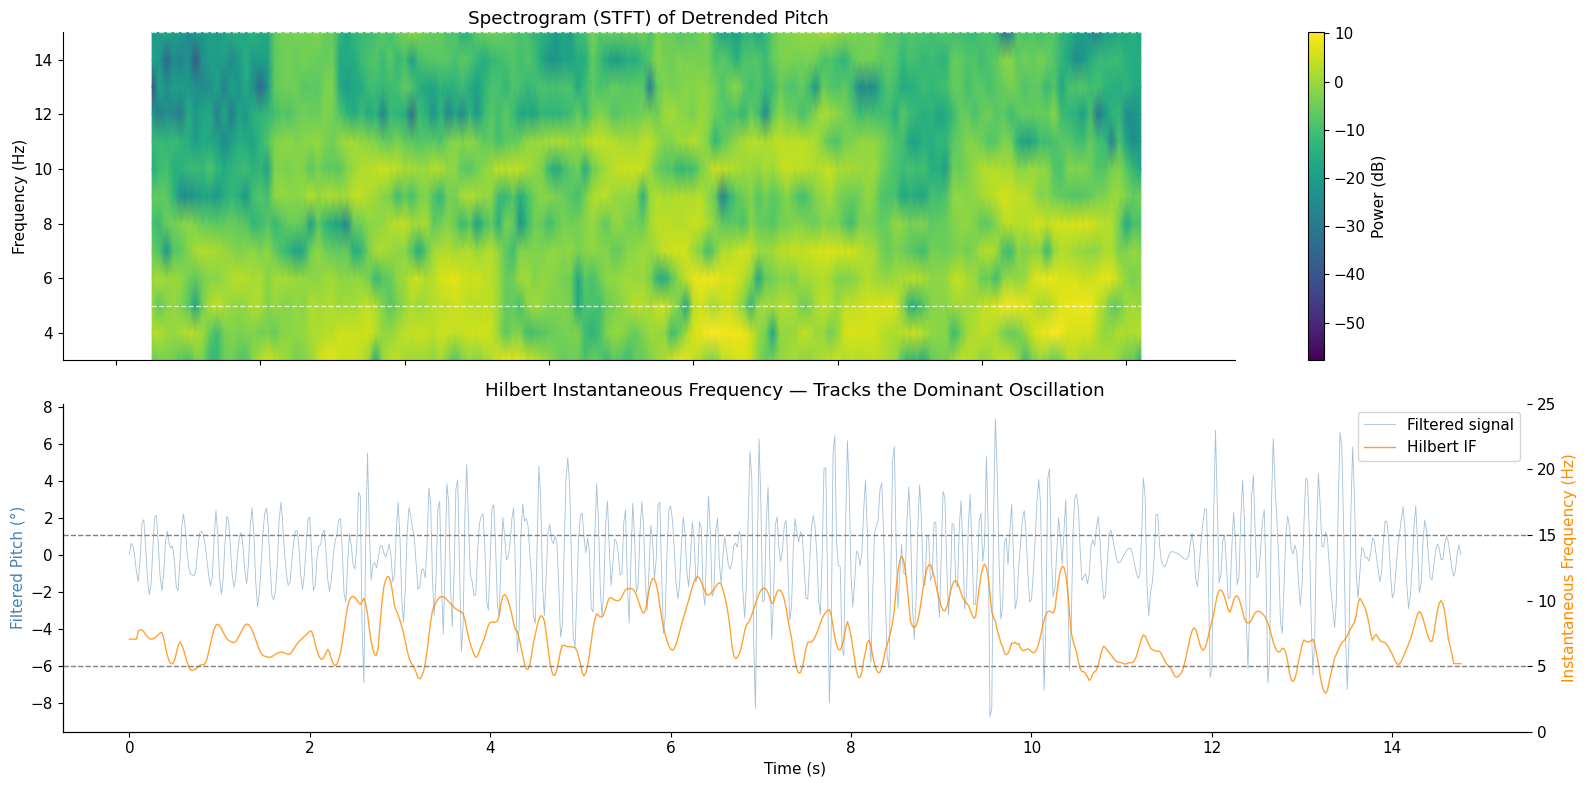

Compare the two panels:
  • The spectrogram shows the full frequency content over time (broadband view)
  • The Hilbert IF tracks the dominant oscillation frequency moment-by-moment
  • Where the spectrogram shows strong 5–15 Hz power, the Hilbert IF should match


In [36]:
# ── Spectrogram vs Hilbert instantaneous frequency ───────────────────────────

# Detrend pitch for spectrogram (same preprocessing as our pipeline)
pitch_unwrapped = np.unwrap(trial['pitch'].values, period=360)
pitch_detrended = pitch_unwrapped - moving_mean_filter(pitch_unwrapped, 10)

# Compute spectrogram
nperseg = int(fs * 1.0)  # 1-second windows
noverlap = int(nperseg * 0.9)  # 90% overlap for smooth display
f_spec, t_spec, Sxx = spectrogram(pitch_detrended, fs=fs,
                                   nperseg=nperseg, noverlap=noverlap)

# ── Plot comparison ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Spectrogram
im = axes[0].pcolormesh(t_spec, f_spec, 10 * np.log10(Sxx + 1e-10),
                         shading='gouraud',)
axes[0].set_ylim(3,15)
axes[0].axhline(5, color='white', linestyle='--', linewidth=1, alpha=0.7)
axes[0].axhline(15, color='white', linestyle='--', linewidth=1, alpha=0.7)
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_title('Spectrogram (STFT) of Detrended Pitch')
plt.colorbar(im, ax=axes[0], label='Power (dB)')

# Hilbert IF overlaid on filtered signal
ax1 = axes[1]
ax1.plot(t_ax, pitch_filt, color='steelblue', linewidth=0.6, alpha=0.5, label='Filtered signal')
ax1_twin = ax1.twinx()
ax1_twin.plot(t_ax, IF, color='darkorange', linewidth=1.0, alpha=0.8, label='Hilbert IF')
ax1_twin.axhline(5, color='grey', linestyle='--', linewidth=1)
ax1_twin.axhline(15, color='grey', linestyle='--', linewidth=1)
ax1_twin.set_ylim(0, 25)
ax1_twin.set_ylabel('Instantaneous Frequency (Hz)', color='darkorange')
ax1.set_ylabel('Filtered Pitch (°)', color='steelblue')
ax1.set_xlabel('Time (s)')
ax1.set_title('Hilbert Instantaneous Frequency — Tracks the Dominant Oscillation')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

print("Compare the two panels:")
print("  • The spectrogram shows the full frequency content over time (broadband view)")
print("  • The Hilbert IF tracks the dominant oscillation frequency moment-by-moment")
print("  • Where the spectrogram shows strong 5–15 Hz power, the Hilbert IF should match")

In [35]:
# ── Quantitative comparison: peak spectrogram frequency vs Hilbert IF ─────────

# For each spectrogram time bin, find the peak frequency in the 5–15 Hz band
band_mask = (f_spec >= 5) & (f_spec <= 15)
peak_freq_spec = f_spec[band_mask][np.argmax(Sxx[band_mask, :], axis=0)]

# Resample Hilbert IF to spectrogram time bins (using nearest-neighbor)
IF_at_spec_times = np.interp(t_spec, t_ax[:-1], IF)

# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(peak_freq_spec, IF_at_spec_times, alpha=0.4, s=15, color='steelblue')
axes[0].plot([5, 15], [5, 15], 'k--', linewidth=1, label='Identity line')
axes[0].set_xlabel('Peak Spectrogram Frequency (Hz)')
axes[0].set_ylabel('Hilbert Instantaneous Frequency (Hz)')
axes[0].set_title('Spectrogram Peak vs Hilbert IF')
axes[0].legend()
axes[0].set_xlim(5, 15)
axes[0].set_ylim(0, 25)

# Correlation
valid = (IF_at_spec_times > 0) & (IF_at_spec_times < 25)
corr = np.corrcoef(peak_freq_spec[valid], IF_at_spec_times[valid])[0, 1]
axes[0].text(0.05, 0.95, f'r = {corr:.3f}', transform=axes[0].transAxes,
             fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Time series overlay
axes[1].plot(t_spec, peak_freq_spec, color='steelblue', linewidth=1.5,
             label='Spectrogram peak freq', alpha=0.8)
axes[1].plot(t_ax[:-1], IF, color='darkorange', linewidth=0.8,
             label='Hilbert IF', alpha=0.6)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_ylim(0, 25)
axes[1].set_title('Both Frequency Estimates Over Time')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Correlation between spectrogram peak and Hilbert IF: r = {corr:.3f}")
print("The Hilbert IF provides much finer temporal resolution than the spectrogram,")
print("but both methods agree on the overall frequency content.")

ValueError: object too deep for desired array

---
## Part 4: Exercises — Interpret the Signal

Now it's your turn! Use the bandpass + Hilbert pipeline to answer biological questions about head-movement rhythms.

### 🎯 Exercise 1: Spatial Map of Instantaneous Frequency

In Findley et al., the authors showed that **sniff frequency is spatially modulated** — higher near the odour source. In our path integration task, is there a spatial pattern to the head-movement rhythm?

**Your task:** Create a 2D heatmap where colour encodes the **mean instantaneous pitch frequency** at each spatial location.

**Math reminder:**

For each position bin $(x_i, z_j)$, compute:

$$\bar{f}(x_i, z_j) = \frac{1}{|\mathcal{T}_{ij}|} \sum_{t \in \mathcal{T}_{ij}} f_{inst}(t)$$

where $\mathcal{T}_{ij}$ is the set of time points when the rat was in bin $(i,j)$.

In [18]:

def spatial_frequency_map(trial_df, IF_signal, n_bins=20):
    """
    Compute a 2D spatial map of mean instantaneous frequency.

    Parameters
    ----------
    trial_df   : DataFrame — single trial data (must have 'x', 'z' columns)
    IF_signal  : 1D array — instantaneous frequency (length = len(trial_df) - 1)
    n_bins     : int — number of spatial bins per axis

    Returns
    -------
    freq_map : 2D array (n_bins, n_bins) — mean IF at each spatial bin (NaN if no data)
    x_edges  : 1D array — bin edges for x
    z_edges  : 1D array — bin edges for z
    """
    x = trial_df['x'].values[:len(IF_signal)]
    z = trial_df['z'].values[:len(IF_signal)]
    x_edges = np.linspace(x.min(), x.max(), n_bins+1)
    z_edges = np.linspace(z.min(), z.max(), n_bins+1)
    xi = np.digitize(x, x_edges) - 1
    zi = np.digitize(z, z_edges) - 1
    freq_map = np.full((n_bins, n_bins), np.nan)
    for i in range(n_bins):
        for j in range(n_bins):
            mask = (xi == i) & (zi == j)
            if mask.sum() > 3:
                freq_map[i, j] = np.nanmean(IF_signal[mask])
    return freq_map, x_edges, z_edges

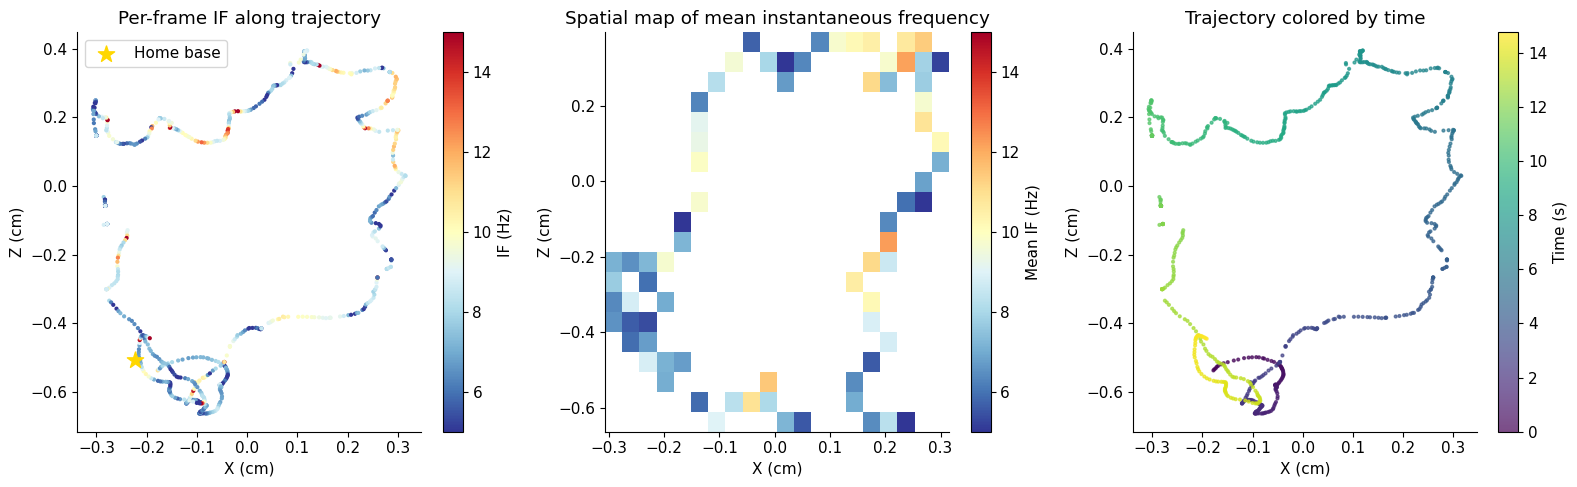

In [19]:
# ── Visualise your spatial map ────────────────────────────────────────────────
# (Run this after completing the function above)

# Get IF from our pipeline
_, _, _, IF_pitch, _ = compute_head_rhythm(trial['pitch'].values, fs)

freq_map, xe, ze = spatial_frequency_map(trial, IF_pitch, n_bins=20)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Per-frame IF along trajectory
sc0 = axes[0].scatter(trial['x'].values[:len(IF_pitch)],
                       trial['z'].values[:len(IF_pitch)],
                       c=IF_pitch, cmap='RdYlBu_r', s=4, vmin=5, vmax=15)
axes[0].scatter(trial['goal_x'].iloc[0], trial['goal_z'].iloc[0],
                s=150, marker='*', color='gold', zorder=6, label='Home base')
axes[0].set_title('Per-frame IF along trajectory')
axes[0].legend()
plt.colorbar(sc0, ax=axes[0], label='IF (Hz)')

# Spatial frequency map
im = axes[1].imshow(freq_map, origin='lower', cmap='RdYlBu_r',
                    vmin=5, vmax=15, aspect='auto',
                    extent=[xe[0], xe[-1], ze[0], ze[-1]])
plt.colorbar(im, ax=axes[1], label='Mean IF (Hz)')
axes[1].set_title('Spatial map of mean instantaneous frequency')

# Trajectory colored by time for reference
sc2 = axes[2].scatter(trial['x'], trial['z'], c=trial['time'],
                       cmap='viridis', s=4, alpha=0.7)
axes[2].set_title('Trajectory colored by time')
plt.colorbar(sc2, ax=axes[2], label='Time (s)')

for ax in axes:
    ax.set_xlabel('X (cm)')
    ax.set_ylabel('Z (cm)')

plt.tight_layout()
plt.show()

# TODO: try different features, such as speed, pitch value, etc that you think might
# help to interpret the spatial map of instantaneous frequency. For example, you could:
# - Color the scatter plot by speed, or by pitch value, or by task phase (outbound vs inbound)

### 🎯 Exercise 2: Apply the Pipeline to All Three Head Angles

So far we have only analysed **pitch**. Now apply the same pipeline to **roll** and **yaw** and compare their rhythmic properties.

**Your task:** Complete the function below to run the pipeline on roll, yaw, and pitch, then plot their instantaneous frequencies side by side.

**Biological hint:**
- **Pitch** (head up/down): related to sniffing and vertical scanning
- **Roll** (head tilt): may reflect active balancing
- **Yaw** (heading direction): might reflect lateral scanning

**Math reminder — Instantaneous frequency:**

$$f_{inst}(t) = \frac{1}{2\pi} \frac{d\phi(t)}{dt}$$

This tells us the *momentary* oscillation rate at each time point, unlike the Fourier spectrum which gives only an average.

In [ ]:
# =============================================================================
# EXERCISE 2: Apply pipeline to roll, yaw, and pitch
# =============================================================================
# TODO: Complete this function.
# HINT: Use compute_head_rhythm() on each angle column.
# HINT: Store the IF and IA for each angle in a dictionary.

def analyse_all_angles(trial_df, fs, lowcut=5.0, highcut=15.0):
    """
    Apply bandpass + Hilbert pipeline to roll, yaw, and pitch.

    Parameters
    ----------
    trial_df : DataFrame — single trial data
    fs       : float — sampling frequency (Hz)
    lowcut   : float — bandpass lower cutoff (Hz)
    highcut  : float — bandpass upper cutoff (Hz)

    Returns
    -------
    results : dict with keys 'roll', 'yaw', 'pitch'
              Each value is a dict: {'IF': array, 'IA': array, 'filtered': array, 't': array}
    """
    results = {}

    for angle in ['roll', 'yaw', 'pitch']:
        # YOUR CODE HERE
        # Step 1: Run compute_head_rhythm on trial_df[angle].values
        # Step 2: Store the results in the dict
        pass

    return results

# Test:
# results = analyse_all_angles(trial, fs)
# for angle in ['roll', 'yaw', 'pitch']:
#     print(f"  {angle:5s}: median IF = {np.nanmedian(results[angle]['IF']):.2f} Hz")

# =============================================================================
# SOLUTION (uncomment to reveal)
# =============================================================================
# def analyse_all_angles(trial_df, fs, lowcut=5.0, highcut=15.0):
#     results = {}
#     for angle in ['roll', 'yaw', 'pitch']:
#         t_ax, filtered, inst_amp, inst_freq, inst_phase = compute_head_rhythm(
#             trial_df[angle].values, fs,
#             lowcut=lowcut, highcut=highcut
#         )
#         results[angle] = {
#             'IF': inst_freq,
#             'IA': inst_amp,
#             'filtered': filtered,
#             't': t_ax,
#         }
#     return results

In [ ]:
# ── Verification ─────────────────────────────────────────────────────────────
# Uncomment after completing the function:

# results = analyse_all_angles(trial, fs)
# for angle in ['roll', 'yaw', 'pitch']:
#     assert angle in results, f"Missing '{angle}' in results"
#     assert 'IF' in results[angle], f"Missing 'IF' for {angle}"
#     print(f"  {angle:5s}: median IF = {np.nanmedian(results[angle]['IF']):.2f} Hz  "
#           f"  mean IA = {np.nanmean(results[angle]['IA']):.3f}°")
# print("✓ All angles analysed!")

  roll : median IF = 7.87 Hz    mean IA = 1.756°
  yaw  : median IF = 7.25 Hz    mean IA = 5.865°
  pitch: median IF = 7.70 Hz    mean IA = 2.804°
✓ All angles analysed!


### 🎯 Exercise 3: Outbound vs Inbound Comparison

The Findley et al. paper found that **active sensing oscillations are modulated by task demands**. In our task, we predict that head movement rhythms may differ between:
- **Outbound** (foraging, uncertain location): higher scanning frequency?
- **Inbound** (homing, relying on path integration): more directed movement?

**Your task:** Split the trial into outbound and inbound phases, compute the mean instantaneous frequency and amplitude for each phase, and visualise the comparison across multiple trials.

**Math reminder — Phase splitting:**

A simple approach: the **outbound phase** ends when the rat reaches maximum distance from home:
$$t_{\text{turn}} = \arg\max_t \, d(t, \text{home})$$

where $d(t, \text{home}) = \sqrt{(x(t) - g_x)^2 + (z(t) - g_z)^2}$

In [22]:
# =============================================================================
# EXERCISE 3: Compare outbound vs inbound head rhythms
# =============================================================================
# TODO: Complete this function.
# HINT: Compute distance from (x, z) to (goal_x, goal_z) at each frame.
# HINT: np.argmax() on the distance array gives the turnaround frame.
# HINT: Outbound = all frames before turnaround; Inbound = after.

def split_outbound_inbound(trial_df):
    """
    Split trial into outbound and inbound phases.

    Returns
    -------
    outbound_mask : boolean array
    inbound_mask  : boolean array
    """
    # YOUR CODE HERE
    # Step 1: Compute distance to goal at each frame
    # Step 2: Find the frame with maximum distance (turnaround)
    # Step 3: Return boolean masks
    pass

# Test:
# out_mask, in_mask = split_outbound_inbound(trial)
# print(f"Outbound frames: {out_mask.sum()}  ({out_mask.sum()/fs:.1f} s)")
# print(f"Inbound frames:  {in_mask.sum()}  ({in_mask.sum()/fs:.1f} s)")

# =============================================================================
# SOLUTION (uncomment to reveal)
# =============================================================================
def split_outbound_inbound(trial_df):
    goal_x = trial_df['goal_x'].values
    goal_z = trial_df['goal_z'].values
    dist   = np.sqrt((trial_df['x'].values - goal_x)**2 +
                     (trial_df['z'].values - goal_z)**2)
    turn_idx      = np.argmax(dist)
    outbound_mask = np.zeros(len(trial_df), dtype=bool)
    inbound_mask  = np.zeros(len(trial_df), dtype=bool)
    outbound_mask[:turn_idx] = True
    inbound_mask[turn_idx:]  = True
    return outbound_mask, inbound_mask

In [23]:
# ── Multi-trial comparison (complete code provided) ──────────────────────────
# This cell runs the full comparison across trials.
# Make sure your split_outbound_inbound function works before running.

def compare_phases_across_trials(df, fs, lowcut=5.0, highcut=15.0, n_trials=5):
    """Compare instantaneous head-movement frequency outbound vs inbound."""
    trial_ids = df['trial_id'].unique()[:n_trials]
    results = []

    for tid in trial_ids:
        t_df = df[df['trial_id'] == tid].copy().reset_index(drop=True)
        if len(t_df) < int(fs * 2):  # skip very short trials
            continue

        try:
            out_mask, in_mask = split_outbound_inbound(t_df)
        except Exception:
            print(f"  Trial {tid}: split function not yet implemented — skipping.")
            continue

        for angle in ['pitch', 'roll']:
            try:
                _, _, IA_sig, IF_sig, _ = compute_head_rhythm(
                    t_df[angle].values, fs,
                    lowcut=lowcut, highcut=highcut
                )
                # IF is 1 sample shorter; align masks
                out_m = out_mask[:len(IF_sig)]
                in_m  = in_mask[:len(IF_sig)]

                results.append({
                    'trial': tid, 'angle': angle,
                    'phase': 'outbound',
                    'mean_IF': np.nanmean(IF_sig[out_m]),
                    'mean_IA': np.nanmean(IA_sig[out_m]),
                })
                results.append({
                    'trial': tid, 'angle': angle,
                    'phase': 'inbound',
                    'mean_IF': np.nanmean(IF_sig[in_m]),
                    'mean_IA': np.nanmean(IA_sig[in_m]),
                })
            except Exception:
                pass

    return pd.DataFrame(results)

# Run (requires Exercise 3 split function)
res_df = compare_phases_across_trials(df, fs, n_trials=138)
if len(res_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = {'outbound': 'steelblue', 'inbound': 'tomato'}
    for ax, angle in zip(axes, ['pitch', 'roll']):
        sub = res_df[res_df['angle'] == angle]
        for phase, grp in sub.groupby('phase'):
            x = np.random.normal(loc=0 if phase == 'outbound' else 1, scale=0.05, size=len(grp))
            ax.scatter(x, grp['mean_IF'], color=colors[phase], alpha=0.7, label=phase.capitalize())
            ax.boxplot(grp['mean_IF'], positions=[0 if phase == 'outbound' else 1],
                       widths=0.3, patch_artist=True,
                       boxprops=dict(facecolor=colors[phase], alpha=0.5))
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Outbound', 'Inbound'])
        ax.set_ylabel('Mean instantaneous frequency (Hz)')
        ax.set_title(f'{angle.capitalize()} rhythm: Outbound vs Inbound')
    plt.tight_layout()
    plt.show()
print("Compare function defined. Complete Exercise 3 to run.")

Compare function defined. Complete Exercise 3 to run.


## Discussion
1. Why do you think the signal is there or not?
2. Is there some confounder that we overlooked?
3. How would you improve?

---
## Part 5: Connecting to the Literature

### What did Findley et al. 2021 find?

In [*Sniff-synchronized, gradient-guided olfactory search by freely moving mice*](https://elifesciences.org/articles/58523) (eLife 2021), the authors tracked mice during an olfactory search task and found:

1. **High-frequency head oscillations (5–15 Hz)** in pitch and roll during active search
2. These oscillations were **phase-locked to the sniff cycle** — the brain coordinates sensory sampling with head movement
3. Oscillation amplitude was **higher near the odour source** — active sensing is spatially modulated
4. The pattern resembles insects' "casting" behaviour — a conserved active sensing strategy

### Our task: Path Integration

In a path integration task, the rat **cannot rely on external cues** during inbound navigation — it must integrate its own movement. We might predict:

| Hypothesis | Prediction |
|------------|------------|
| **Active sensing during outbound** | Higher head oscillation frequency / amplitude outbound |
| **Motor efficiency inbound** | Reduced, more directional head movements inbound |
| **Stress/uncertainty modulation** | Oscillations increase when distance to home is large |

### Reflection Questions

1. Did you find a difference in instantaneous pitch/roll frequency between outbound and inbound phases?
2. Is the signal in the 5–15 Hz band truly rhythmic, or is it noise? How would you distinguish them?
3. What additional measurements (e.g., sniffing, whisking) would you need to confirm that head oscillations reflect active sensing in this task?

---

## Summary & Key Takeaways

- **Bandpass filtering** isolates frequency bands but assumes stationarity — always check with a power spectrum
- **The Hilbert transform** constructs an analytic signal, giving instantaneous frequency and amplitude — much richer than a single power spectrum
- **Spectrograms** provide a time-frequency overview; the Hilbert IF provides fine-grained tracking of a narrowband oscillation
- Head movements in rats during navigation show rhythmic oscillations that may reflect active sensing strategies
- Connecting kinematics to behaviour requires linking signal properties (frequency, amplitude) to task context (outbound vs inbound)

## Extension Reading

- Findley et al. 2021, *eLife* — [Sniff-synchronized, gradient-guided olfactory search](https://elifesciences.org/articles/58523)
- Cohen 2014 — *Analyzing Neural Time Series Data* (Chapter on Hilbert transform)
- Boashash 1992 — *Estimating and interpreting the instantaneous frequency of a signal*

---
---

# 🌟 BONUS: Empirical Mode Decomposition (EMD) + Hilbert Transform

> **This section is optional.** It covers an advanced, data-driven alternative to bandpass filtering. Read it if you want to go deeper!

## Why EMD? The Problem with Simple Bandpass Filtering

A bandpass filter assumes the signal is **stationary** — that its frequency content doesn't change over time. But biological signals like head movements are **non-stationary**: the rat may oscillate faster during active sensing and slower during rest.

**Empirical Mode Decomposition (EMD)** is a data-driven method that decomposes a signal into **Intrinsic Mode Functions (IMFs)** — oscillatory components that:
- Are locally symmetric (mean ≈ 0 at every point)
- Have exactly one zero crossing between each pair of extrema

$$x(t) = \sum_{k=1}^{K} \text{IMF}_k(t) + r(t)$$

where $r(t)$ is the residual (slow trend). Each IMF captures a different timescale of variation.

### The EMD + Hilbert Pipeline

Instead of applying the Hilbert transform to a bandpass-filtered signal, we can:
1. EMD: decompose into IMFs (no fixed frequency band needed!)
2. Hilbert transform each IMF → get instantaneous frequency & amplitude per component
3. Select the IMF(s) whose frequency falls in our target band

This is more flexible than bandpass filtering because:
- It adapts to the signal's actual oscillatory structure
- It doesn't assume a fixed frequency band

In [ ]:
# ── BONUS: Install and import EMD library ────────────────────────────────────
!pip install emd -q
import emd

print(f"✓ emd version: {emd.__version__}")

In [ ]:
# ── BONUS: EMD + Hilbert pipeline ────────────────────────────────────────────

def compute_head_rhythm_emd(angle_signal, fs,
                            lowcut=5.0, highcut=15.0,
                            filter_order=2, smooth_window=10,
                            smooth_freq=9, smooth_phase=5):
    """
    Full pipeline using EMD: angle signal → instantaneous frequency & amplitude.

    Steps
    -----
    1. Unwrap angle (handle 360° wrapping)
    2. Remove slow drift (moving average)
    3. Bandpass filter (isolate target frequency band)
    4. EMD: decompose into Intrinsic Mode Functions
    5. Hilbert transform: extract instantaneous phase, frequency, amplitude per IMF

    Returns
    -------
    t_axis, filtered, imfs, IP, IF, IA
    """
    # Step 1–3: Same preprocessing
    unwrapped = np.unwrap(angle_signal, period=360)
    detrended = unwrapped - moving_mean_filter(unwrapped, smooth_window)
    filtered = butter_bandpass_filter(detrended, lowcut, highcut, fs, filter_order)

    # Step 4: EMD — decompose filtered signal into IMFs
    imfs = emd.sift.sift(filtered)

    # Step 5: Hilbert transform on all IMFs (emd library's built-in)
    IP, IF, IA = emd.spectra.frequency_transform(
        imfs, fs, 'hilbert',
        smooth_freq=smooth_freq,
        smooth_phase=smooth_phase
    )

    t_axis = np.arange(len(filtered)) / fs
    return t_axis, filtered, imfs, IP, IF, IA


# Run EMD pipeline
print("Running EMD pipeline on trial pitch signal...")
t_emd, filt_emd, imfs, IP, IF_emd, IA_emd = compute_head_rhythm_emd(
    trial['pitch'].values, fs
)

print(f"  IMFs found: {imfs.shape[1]}")
for k in range(imfs.shape[1]):
    print(f"    IMF {k+1}: median freq = {np.nanmedian(IF_emd[:, k]):.1f} Hz, "
          f"mean amp = {np.nanmean(IA_emd[:, k]):.3f}°")
print("\n✓ EMD pipeline complete!")

In [ ]:
# ── BONUS: Visualise EMD decomposition ───────────────────────────────────────

n_imfs = imfs.shape[1]
mean_if = np.nanmedian(IF_emd, axis=0)

# Find best IMF in target band
in_band = (mean_if >= 5) & (mean_if <= 15)
if in_band.any():
    best_idx = np.where(in_band)[0][int(np.argmax(IA_emd[:, in_band].mean(axis=0)))]
else:
    best_idx = 0

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# IMFs
offset = 0
for k in range(min(n_imfs, 5)):
    axes[0].plot(t_emd, imfs[:, k] + offset, linewidth=0.8,
                 label=f'IMF {k+1} (median f={mean_if[k]:.1f} Hz)', alpha=0.85)
    offset += np.ptp(imfs[:, k]) * 1.2
axes[0].set_ylabel('Amplitude (°, offset)')
axes[0].set_title('EMD Intrinsic Mode Functions')
axes[0].legend(fontsize=8, loc='upper right')

# Best IMF + envelope
axes[1].plot(t_emd, imfs[:, best_idx], color='steelblue', linewidth=0.9, alpha=0.8,
             label=f'IMF {best_idx+1}')
axes[1].plot(t_emd, IA_emd[:, best_idx], color='crimson', linewidth=1.5,
             label='Envelope (IA)')
axes[1].plot(t_emd, -IA_emd[:, best_idx], color='crimson', linewidth=1.5, alpha=0.5)
axes[1].set_ylabel('Amplitude (°)')
axes[1].set_title(f'Best IMF in 5–15 Hz band (IMF {best_idx+1}) + Envelope')
axes[1].legend()

# Instantaneous frequency
axes[2].plot(t_emd, IF_emd[:, best_idx], color='darkorange', linewidth=0.9, alpha=0.8)
axes[2].axhline(5, color='grey', linestyle='--', linewidth=1)
axes[2].axhline(15, color='grey', linestyle='--', linewidth=1)
axes[2].set_ylim(0, 25)
axes[2].set_ylabel('Frequency (Hz)')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('Instantaneous Frequency (EMD + Hilbert)')

plt.tight_layout()
plt.show()

print(f"\nCompare this with the direct Hilbert IF from Part 3.")
print(f"EMD provides a cleaner decomposition when the signal has multiple oscillatory components.")

### When to Use EMD vs Direct Hilbert?

| Approach | Pros | Cons | Best for |
|----------|------|------|----------|
| **Bandpass + Hilbert** | Simple, fast, few parameters | Assumes fixed frequency band; requires stationarity | When you know the frequency band of interest |
| **EMD + Hilbert** | Data-driven, handles non-stationarity | More complex, sensitive to parameters, can produce spurious IMFs | Exploratory analysis; signals with unknown frequency structure |

For our head-movement analysis, the **bandpass + Hilbert** approach is often sufficient because we have a clear hypothesis about the frequency band (5–15 Hz from the Findley et al. literature). EMD becomes more useful when you want to discover oscillatory structure without prior assumptions.